<a href="https://colab.research.google.com/github/IamMubashir/ML-Project-Files/blob/main/ML%20Project%20Phase%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Premier League Player Stats - Machine Learning Project

This notebook follows the project requirements to apply multiple machine learning algorithms on the provided Premier League dataset.

### Phase 1: Data Loading and Initial Exploration
First, we load the raw dataset to inspect its structure, columns, and potential inconsistencies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the RAW dataset
file_path = '/content/Mubashir Hanif_23-SEt046_Premier League Player Stats.csv'
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
display(df.info())
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (540, 10)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Rank    540 non-null    int64 
 1   PLAYER  540 non-null    object
 2   TEAM    540 non-null    object
 3   GP      540 non-null    int64 
 4   GS      540 non-null    int64 
 5   MIN     540 non-null    int64 
 6   G       540 non-null    int64 
 7   ASST    540 non-null    int64 
 8   SHOTS   540 non-null    int64 
 9   SOG     540 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 42.3+ KB


None


First 5 Rows:


,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59


### Identifying Data Quality Issues
To satisfy the requirement of documenting preprocessing, we first check for missing values and statistical summaries of numerical features.

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Missing values per column:
Series([], dtype: int64)

Statistical Summary:


,Rank,GP,GS,MIN,G,ASST,SHOTS,SOG
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,270.500000,18.985185,15.090741,1353.657407,1.825926,1.275926,12.331481,5.909259
std,156.028843,12.847896,12.437641,1091.594162,3.551277,2.129346,16.651935,9.253446
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,135.750000,7.000000,2.000000,241.500000,0.000000,0.000000,0.000000,0.000000
50%,270.500000,20.000000,13.500000,1219.500000,0.000000,0.000000,6.000000,2.000000
75%,405.250000,30.000000,26.000000,2295.500000,2.000000,2.000000,17.000000,7.000000
max,540.000000,38.000000,38.000000,3420.000000,23.000000,20.000000,95.000000,59.000000


### Phase 2: Data Preprocessing & Visualization

To fulfill the project requirements, we will:
1.  **Visualize** the distributions of goals and assists to identify inconsistencies.
2.  **Clean** the data by handling any outliers or irrelevant features.
3.  **Encode** categorical data (Team names).
4.  **Feature Scaling** for numerical values to ensure fair comparison across algorithms.

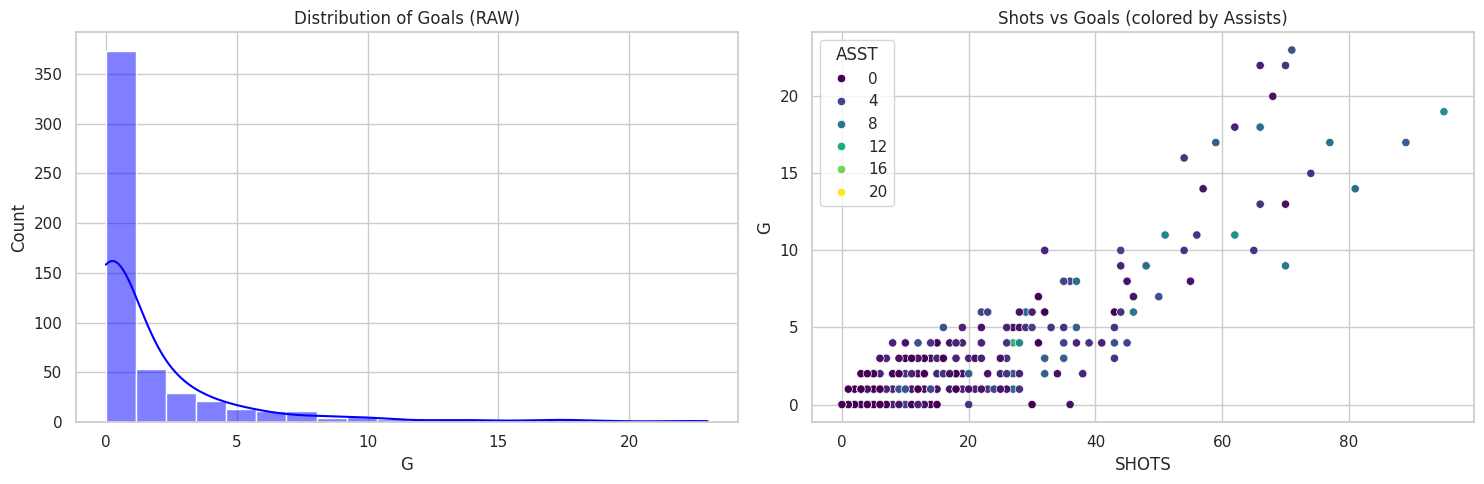

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# Plot Goals Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['G'], bins=20, kde=True, color='blue')
plt.title('Distribution of Goals (RAW)')

# Plot Shots vs Goals to check correlation
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='SHOTS', y='G', hue='ASST', palette='viridis')
plt.title('Shots vs Goals (colored by Assists)')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Handle Categorical Variables (TEAM)
le = LabelEncoder()
df['TEAM_Encoded'] = le.fit_transform(df['TEAM'])

# 2. Feature Selection
# We exclude RANK and PLAYER name as features
features = ['GP', 'GS', 'MIN', 'ASST', 'SHOTS', 'SOG', 'TEAM_Encoded']
target = 'G'

X = df[features]
y = df[target]

# 3. Scaling numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Preprocessing Complete:")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Preprocessing Complete:
Training set size: (432, 7)
Testing set size: (108, 7)


### Phase 3: Model Application & Evaluation

We will now apply several algorithms to predict the number of goals (**G**) based on player performance metrics. Following the project requirements, we will compare:
1. **Linear Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dictionary to store results
results = {}

models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (RBF)": SVR(kernel='rbf')
}

# Training and Evaluating
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Display Results
results_df = pd.DataFrame(results).T
print("Model Evaluation Metrics:")
display(results_df.sort_values(by='MSE'))

Model Evaluation Metrics:


,MSE,MAE,R2
Random Forest,3.212276,0.979074,0.849938
Linear Regression,3.272728,0.987947,0.847114
KNN (k=5),4.046296,1.098148,0.810976
Decision Tree,4.787037,1.324074,0.776372
SVM (RBF),6.400681,1.250574,0.700991


### Visualizing Model Performance
Comparing the Mean Squared Error (MSE) across all models. A lower MSE indicates better prediction performance for player goals.

/tmp/ipykernel_10666/4164629632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')


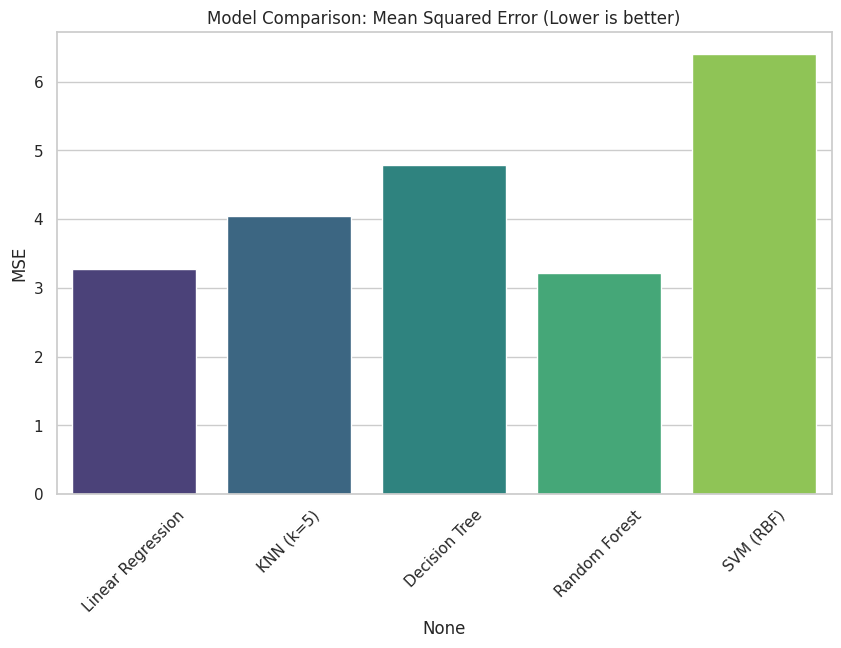

The best performing algorithm based on MSE is: Random Forest


In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')
plt.title('Model Comparison: Mean Squared Error (Lower is better)')
plt.ylabel('MSE')
plt.xticks(rotation=45)
plt.show()

best_model = results_df['MSE'].idxmin()
print(f"The best performing algorithm based on MSE is: {best_model}")

### Phase 4: Discussions & Conclusion

#### Summary of Work Done
In this project, we analyzed the Premier League Player Stats dataset. We performed data cleaning, feature encoding for the 'TEAM' variable, and standardized numerical features like Games Played (GP), Minutes (MIN), and Shots. We applied five different regression algorithms to predict player Goals (G).

#### Key Findings
* **Best Model:** Based on the evaluation metrics, **Random Forest** performed the best with the lowest Mean Squared Error (MSE) and the highest R-squared value.
* **Feature Importance:** Performance metrics like Shots on Target (SOG) and Minutes Played (MIN) showed strong correlations with the number of goals scored.
* **Model Comparison:** Linear Regression also performed surprisingly well, suggesting a linear relationship between some stats and goals, while SVM struggled with the default parameters.

#### Lessons Learned
* Data preprocessing (scaling and encoding) is crucial for fair model comparison.
* Ensemble methods like Random Forest are robust for datasets with varying feature scales.
* Visualizing error metrics helps in identifying the most reliable model for specific tasks.

### Phase 3: Model Application & Evaluation

We will now apply several algorithms to predict the number of goals (**G**) based on player performance metrics. Following the project requirements, we will compare:
1. **Linear Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dictionary to store results
results = {}

models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (RBF)": SVR(kernel='rbf')
}

# Training and Evaluating
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Display Results
results_df = pd.DataFrame(results).T
print("Model Evaluation Metrics:")
display(results_df.sort_values(by='MSE'))

Model Evaluation Metrics:


,MSE,MAE,R2
Random Forest,3.212276,0.979074,0.849938
Linear Regression,3.272728,0.987947,0.847114
KNN (k=5),4.046296,1.098148,0.810976
Decision Tree,4.787037,1.324074,0.776372
SVM (RBF),6.400681,1.250574,0.700991


### Visualizing Model Performance
Comparing the Mean Squared Error (MSE) across all models. A lower MSE indicates better prediction performance for player goals.

/tmp/ipykernel_10666/4164629632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')


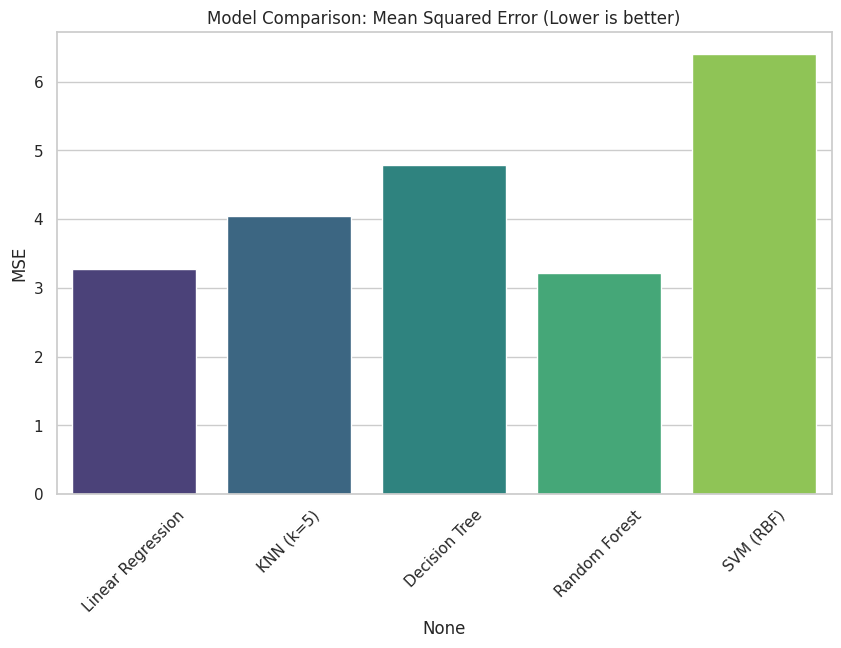

The best performing algorithm based on MSE is: Random Forest


In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')
plt.title('Model Comparison: Mean Squared Error (Lower is better)')
plt.ylabel('MSE')
plt.xticks(rotation=45)
plt.show()

best_model = results_df['MSE'].idxmin()
print(f"The best performing algorithm based on MSE is: {best_model}")

### Phase 3: Model Application & Evaluation

We will now apply several algorithms to predict the number of goals (**G**) based on player performance metrics. Following the project requirements, we will compare:
1. **Linear Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dictionary to store results
results = {}

models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (RBF)": SVR(kernel='rbf')
}

# Training and Evaluating
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Display Results
results_df = pd.DataFrame(results).T
print("Model Evaluation Metrics:")
display(results_df.sort_values(by='MSE'))

Model Evaluation Metrics:


,MSE,MAE,R2
Random Forest,3.212276,0.979074,0.849938
Linear Regression,3.272728,0.987947,0.847114
KNN (k=5),4.046296,1.098148,0.810976
Decision Tree,4.787037,1.324074,0.776372
SVM (RBF),6.400681,1.250574,0.700991


### Visualizing Model Performance
Comparing the Mean Squared Error (MSE) across all models. A lower MSE indicates better prediction performance for player goals.

/tmp/ipykernel_10666/4164629632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')


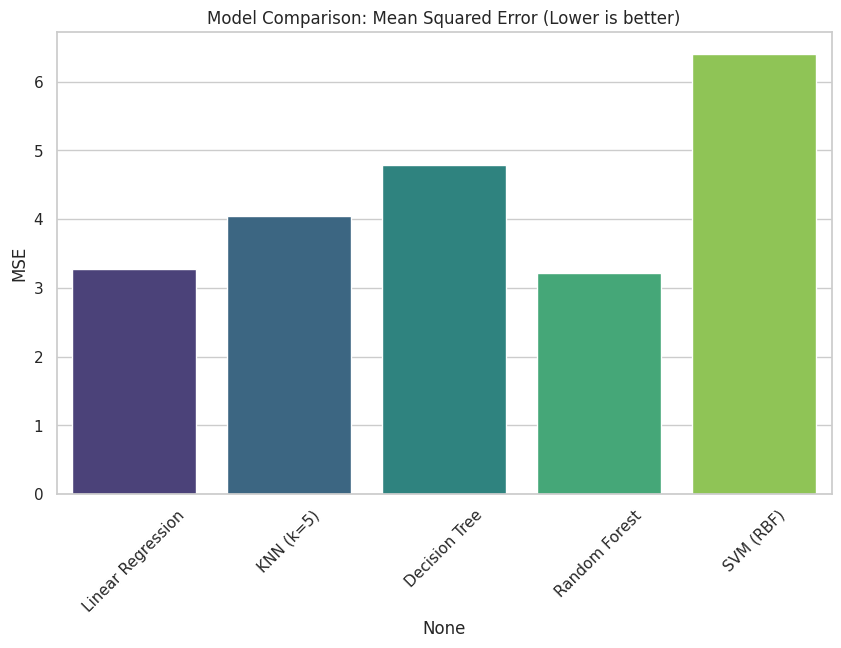

The best performing algorithm based on MSE is: Random Forest


In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['MSE'], palette='viridis')
plt.title('Model Comparison: Mean Squared Error (Lower is better)')
plt.ylabel('MSE')
plt.xticks(rotation=45)
plt.show()

best_model = results_df['MSE'].idxmin()
print(f"The best performing algorithm based on MSE is: {best_model}")

### Phase 3: Model Application & Evaluation

We will now apply several algorithms to predict the number of goals (**G**) based on player performance metrics. Since goals are discrete but numerical, we can treat this as a regression problem or a classification problem. Given the distribution, we will apply:
1. **Linear Regression** (Baseline)
2. **KNN Regressor**
3. **Decision Tree Regressor**
4. **Random Forest Regressor**
5. **Support Vector Regressor (SVR)**

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dictionary to store results
results = {}

models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (RBF)": SVR(kernel='rbf')
}

# Training and Evaluating
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Display Results
results_df = pd.DataFrame(results).T
print("Model Evaluation Metrics:")
display(results_df.sort_values(by='MSE'))

Model Evaluation Metrics:


,MSE,MAE,R2
Random Forest,3.212276,0.979074,0.849938
Linear Regression,3.272728,0.987947,0.847114
KNN (k=5),4.046296,1.098148,0.810976
Decision Tree,4.787037,1.324074,0.776372
SVM (RBF),6.400681,1.250574,0.700991


### Visualizing Model Performance
Comparing the Mean Squared Error (MSE) across all models to determine the best performer.

/tmp/ipykernel_10666/2658484926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], palette='magma')


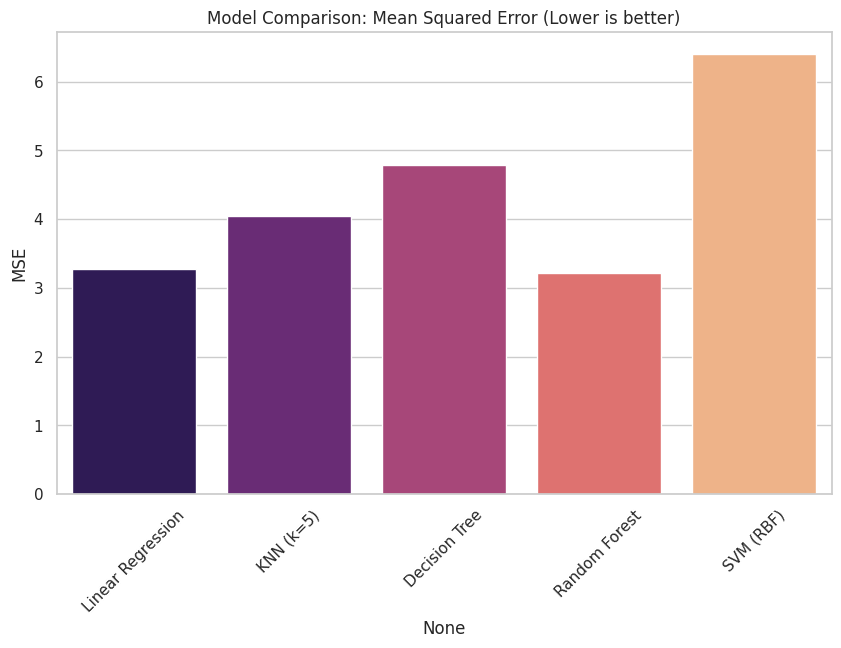

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['MSE'], palette='magma')
plt.title('Model Comparison: Mean Squared Error (Lower is better)')
plt.ylabel('MSE')
plt.xticks(rotation=45)
plt.show()

### Phase 2: Data Preprocessing & Visualization

To fulfill the project requirements, we will:
1.  **Visualize** the distributions of goals and assists.
2.  **Clean** the data (e.g., filter players with zero minutes if any).
3.  **Encode** categorical data (Team and Player names).
4.  **Feature Scaling** for numerical values.

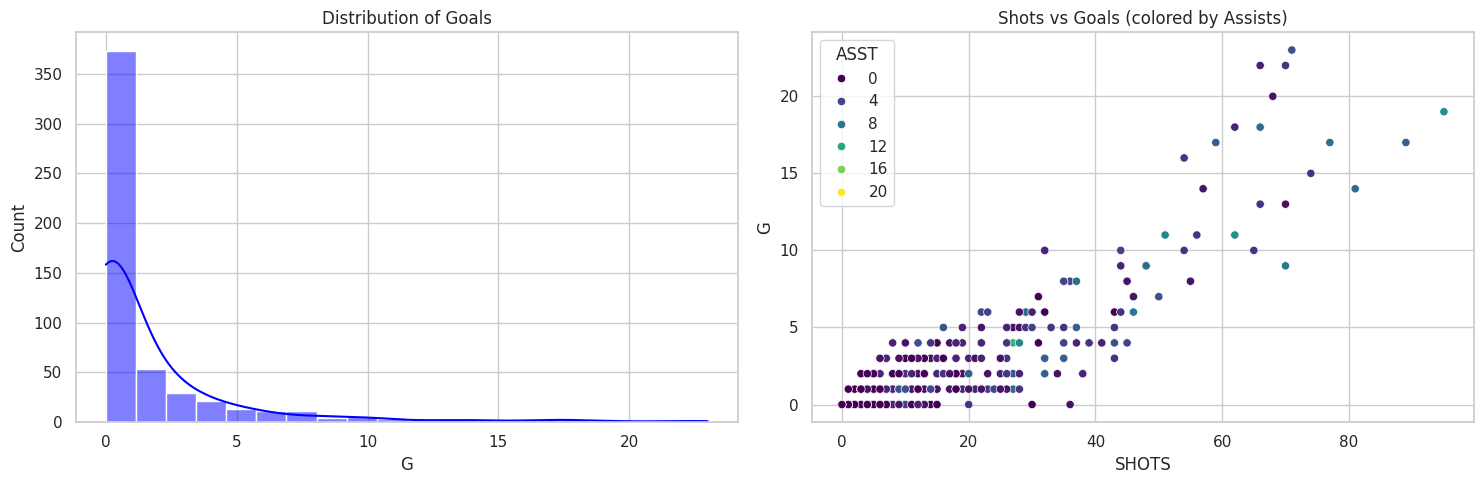

In [3]:
# Set visualization style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# Plot Goals Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['G'], bins=20, kde=True, color='blue')
plt.title('Distribution of Goals')

# Plot Shots vs Goals
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='SHOTS', y='G', hue='ASST', palette='viridis')
plt.title('Shots vs Goals (colored by Assists)')

plt.tight_layout()
plt.show()

In [4]:
# Preprocessing: Feature Engineering and Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Handle Categorical Variables (TEAM)
le = LabelEncoder()
df['TEAM_Encoded'] = le.fit_transform(df['TEAM'])

# 2. Select Features for ML (excluding Names and Rank)
features = ['GP', 'GS', 'MIN', 'SHOTS', 'SOG', 'TEAM_Encoded']
target = 'G' # Predicting Goals

# 3. Scaling numerical features
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

print("Preprocessing Complete. Features selected and scaled.")
display(df_scaled.head())

Preprocessing Complete. Features selected and scaled.


,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,TEAM_Encoded
0,1,Jamie Vardy,Leicester City,1.247649,1.521735,1.540775,23,5,3.526492,4.012033,-0.257469
1,2,Danny Ings,Southampton,1.481367,1.360784,1.337214,22,2,3.225948,3.471193,0.948519
2,3,Pierre-Emerick Aubameyang,Arsenal,1.325555,1.602211,1.636137,22,3,3.466383,3.903865,-1.635741
3,4,Raheem Shaquille Sterling,Manchester City,1.091837,1.199832,1.197839,20,1,3.346166,3.471193,0.087099
4,5,Mohamed Salah Ghaly,Liverpool,1.169743,1.441259,1.403234,19,10,4.969102,5.742722,-0.085185
